In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import timm
import wandb
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm

device = torch.device('cuda')
print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"Free : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1024**3:.1f}GB")

with open('../data/data_config.pkl', 'rb') as f:
    config = pickle.load(f)

CLASSES    = config['classes']
IMAGE_SIZE = config['image_size']
test_df    = config['test_df']
SEG_DIR    = '../data/segmented_images'

os.makedirs('../results/attention_rollout', exist_ok=True)

print(f"Classes : {len(CLASSES)}")
print(f"Test    : {len(test_df):,}")
print("✅ Setup done!")

/home/lhotse1/student/btech2023/achanta/miniconda3/envs/cv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU  : Tesla V100-PCIE-32GB
Free : 31.7GB
Classes : 15
Test    : 22,424
✅ Setup done!


In [2]:
wandb.init(
    project='xray-classification',
    name='04c-attention-rollout',
    config={
        'method': 'Attention Rollout',
        'model': 'ViT',
        'bbox_images': 880,
        'iou_threshold': 0.5
    }
)
print("✅ Wandb initialized!")

wandb: Currently logged in as: chandinigunna06 (chandinigunna06-iiest-shibpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ Wandb initialized!


In [3]:
vit = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=len(CLASSES))
vit.load_state_dict(torch.load('../checkpoints/ViT/best.pt', map_location=device, weights_only=False)['model_state'])
vit = vit.to(device).eval()
print("✅ ViT loaded!")

# Sanity check patch grid size matches IMAGE_SIZE
patch_size = vit.patch_embed.patch_size[0]
n_patches_per_side = IMAGE_SIZE // patch_size
print(f"Patch size: {patch_size}, grid: {n_patches_per_side}x{n_patches_per_side}")

✅ ViT loaded!
Patch size: 16, grid: 14x14


In [8]:
attention_maps = []

def hook_fn(module, input, output):
    # timm ViT attention module returns weighted output only by default;
    # we need to patch forward to capture the softmax attention matrix
    pass

# timm's Attention block doesn't expose attn weights by default — patch it
def attn_forward_wrapper(attn_module):
    def forward(x, attn_mask=None, is_causal=False):
        B, N, C = x.shape
        qkv = attn_module.qkv(x).reshape(B, N, 3, attn_module.num_heads, C // attn_module.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * attn_module.scale
        attn = attn.softmax(dim=-1)
        attention_maps.append(attn.detach())
        attn = attn_module.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = attn_module.proj(x)
        x = attn_module.proj_drop(x)
        return x
    return forward
# Patch all attention blocks
for block in vit.blocks:
    block.attn.forward = attn_forward_wrapper(block.attn)

print(f"✅ Patched {len(vit.blocks)} attention blocks for rollout capture")

def attention_rollout(attn_maps, discard_ratio=0.0, head_fusion='mean'):
    """
    attn_maps: list of [B, heads, N, N] tensors, one per layer
    Returns rollout mask over patch tokens (excludes CLS), shape [B, N-1]
    """
    result = torch.eye(attn_maps[0].size(-1)).unsqueeze(0).to(attn_maps[0].device)
    result = result.repeat(attn_maps[0].size(0), 1, 1)

    for attn in attn_maps:
        if head_fusion == 'mean':
            attn_fused = attn.mean(dim=1)   # [B, N, N]
        elif head_fusion == 'max':
            attn_fused = attn.max(dim=1)[0]
        else:
            attn_fused = attn.min(dim=1)[0]

        # Add residual connection (identity) — this is what makes it "rollout"
        I = torch.eye(attn_fused.size(-1)).unsqueeze(0).to(attn_fused.device)
        a = (attn_fused + I) / 2
        a = a / a.sum(dim=-1, keepdim=True)

        result = torch.bmm(a, result)

    # CLS token's attention to all patch tokens (row 0, skip col 0 which is CLS→CLS)
    mask = result[:, 0, 1:]
    return mask

print("✅ Rollout function defined!")

✅ Patched 12 attention blocks for rollout capture
✅ Rollout function defined!


In [9]:
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

bbox_df = pd.read_csv('../data/NIH/BBox_List_2017_Official_NIH.csv')
bbox_df = bbox_df.rename(columns={'Bbox [x': 'x', 'y': 'y', 'w': 'w', 'h]': 'h'})
bbox_df = bbox_df[['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']]

label_map = {'Infiltrate': 'Infiltration'}
bbox_df['Finding Label'] = bbox_df['Finding Label'].replace(label_map)
bbox_df = bbox_df[bbox_df['Finding Label'].isin(CLASSES)].reset_index(drop=True)

ORIGINAL_RES = 1024
scale = IMAGE_SIZE / ORIGINAL_RES
bbox_df['x_scaled'] = bbox_df['x'] * scale
bbox_df['y_scaled'] = bbox_df['y'] * scale
bbox_df['w_scaled'] = bbox_df['w'] * scale
bbox_df['h_scaled'] = bbox_df['h'] * scale

print(f"✅ {len(bbox_df)} bbox annotations ready, scale={scale:.4f}")

✅ 984 bbox annotations ready, scale=0.2188


In [10]:
def rollout_to_heatmap(mask, n_patches_per_side, img_size):
    """Reshape flat patch-relevance vector into a full-res heatmap"""
    mask = mask.reshape(n_patches_per_side, n_patches_per_side).cpu().numpy()
    mask = mask / (mask.max() + 1e-8)   # normalize to [0,1]
    heatmap = np.array(Image.fromarray(mask).resize((img_size, img_size), Image.BILINEAR))
    return heatmap

def cam_to_bbox_mask(heatmap, threshold=0.5):
    return (heatmap >= threshold).astype(np.uint8)

def gt_bbox_to_mask(x, y, w, h, img_size):
    mask = np.zeros((img_size, img_size), dtype=np.uint8)
    x1, y1 = max(0, int(round(x))), max(0, int(round(y)))
    x2, y2 = min(img_size, int(round(x + w))), min(img_size, int(round(y + h)))
    mask[y1:y2, x1:x2] = 1
    return mask

def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

print("✅ Helper functions defined!")

✅ Helper functions defined!


In [11]:
ious = []
detailed_records = []

with torch.no_grad():
    for idx, row in tqdm(bbox_df.iterrows(), total=len(bbox_df), desc="AttnRollout + IoU"):
        fname = row['Image Index']
        gt_label = row['Finding Label']
        if gt_label not in CLASSES:
            continue

        img_path = os.path.join(SEG_DIR, fname)
        img = Image.open(img_path).convert('RGB')
        input_tensor = val_transform(img).unsqueeze(0).to(device)

        attention_maps.clear()
        _ = vit(input_tensor)   # forward pass populates attention_maps via hooks

        mask = attention_rollout(attention_maps, head_fusion='mean')
        heatmap = rollout_to_heatmap(mask[0], n_patches_per_side, IMAGE_SIZE)

        gt_mask = gt_bbox_to_mask(row['x_scaled'], row['y_scaled'], row['w_scaled'], row['h_scaled'], IMAGE_SIZE)
        cam_mask = cam_to_bbox_mask(heatmap, threshold=0.5)

        iou = compute_iou(cam_mask, gt_mask)
        ious.append(iou)
        detailed_records.append({'Image Index': fname, 'Finding Label': gt_label, 'Model': 'ViT', 'IoU': iou})

print("\n✅ Attention Rollout + IoU computed!")

AttnRollout + IoU: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 984/984 [00:45<00:00, 21.61it/s]


✅ Attention Rollout + IoU computed!


In [12]:
mean_iou = np.mean(ious)
print("="*60)
print("  Attention Rollout vs Ground-Truth BBox — ViT")
print("="*60)
print(f"ViT (Attention Rollout) → Mean IoU: {mean_iou:.4f}  (n={len(ious)})")

summary_vit = {'ViT': round(mean_iou, 4)}

# Compare against CNN GradCAM++ results for context
try:
    with open('../data/gradcam_plus_iou_results.pkl', 'rb') as f:
        cnn_summary = pickle.load(f)['summary']
    print("\n  Model            Mean IoU")
    print("  " + "-"*30)
    combined = {**cnn_summary, **summary_vit}
    for m, v in sorted(combined.items(), key=lambda x: -x[1]):
        print(f"  {m:15s}  {v:.4f}")
except FileNotFoundError:
    print("\n⚠️ 04b results not found — run 04b_gradcam_plus.ipynb first for comparison")

iou_df = pd.DataFrame(detailed_records)

  Attention Rollout vs Ground-Truth BBox — ViT
ViT (Attention Rollout) → Mean IoU: 0.1246  (n=984)

  Model            Mean IoU
  ------------------------------
  VGG16            0.1806
  DenseNet121      0.1722
  ConvNeXt         0.1480
  EfficientNet     0.1281
  ViT              0.1246
  ResNet50         0.1199


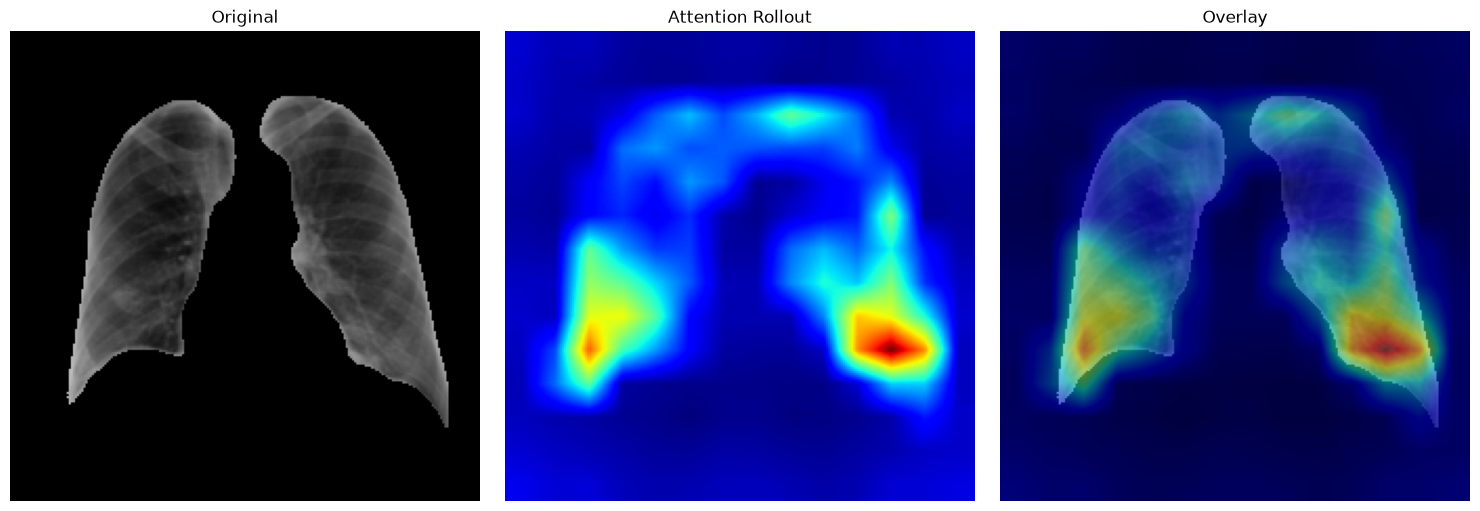

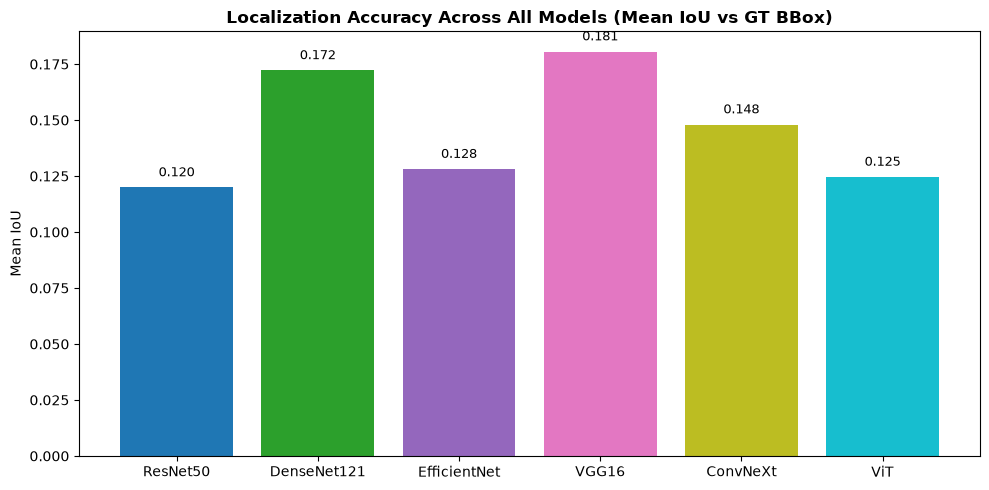

attn_rollout_mean_iou_vit,▁
attn_rollout_mean_iou_vit,0.1246


✅ attention_rollout_iou_results.pkl saved!
✅ Results logged to wandb!
👉 Next: 05_report_compilation.ipynb — pulls all summary pickles into final figures/tables


In [13]:
# Grab one example to visualize
sample_row = bbox_df.iloc[0]
img = Image.open(os.path.join(SEG_DIR, sample_row['Image Index'])).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
input_tensor = val_transform(Image.open(os.path.join(SEG_DIR, sample_row['Image Index'])).convert('RGB')).unsqueeze(0).to(device)

attention_maps.clear()
with torch.no_grad():
    _ = vit(input_tensor)
mask = attention_rollout(attention_maps, head_fusion='mean')
heatmap = rollout_to_heatmap(mask[0], n_patches_per_side, IMAGE_SIZE)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(heatmap, cmap='jet'); axes[1].set_title('Attention Rollout'); axes[1].axis('off')
axes[2].imshow(img); axes[2].imshow(heatmap, cmap='jet', alpha=0.5); axes[2].set_title('Overlay'); axes[2].axis('off')
plt.tight_layout()04d_lime.
plt.savefig('../results/attention_rollout/sample_overlay.png', dpi=150)
plt.show()

# Bar chart comparing all models
fig, ax = plt.subplots(figsize=(10, 5))
try:
    combined = {**cnn_summary, **summary_vit}
except NameError:
    combined = summary_vit
names, values = list(combined.keys()), list(combined.values())
colors = plt.cm.tab10(np.linspace(0, 1, len(names)))
ax.bar(names, values, color=colors)
ax.set_title('Localization Accuracy Across All Models (Mean IoU vs GT BBox)', fontweight='bold')
ax.set_ylabel('Mean IoU')
for i, v in enumerate(values):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/attention_rollout/all_models_iou_comparison.png', dpi=150)
plt.show()

with open('../data/attention_rollout_iou_results.pkl', 'wb') as f:
    pickle.dump({'summary': summary_vit, 'detailed_records': detailed_records, 'iou_df': iou_df}, f)

wandb.log({
    'attn_rollout_mean_iou_vit': summary_vit['ViT'],
    'attn_rollout_sample_overlay': wandb.Image('../results/attention_rollout/sample_overlay.png'),
    'all_models_iou_chart': wandb.Image('../results/attention_rollout/all_models_iou_comparison.png')
})
wandb.finish()

print("✅ attention_rollout_iou_results.pkl saved!")
print("✅ Results logged to wandb!")
print("👉 Next: 05_report_compilation.ipynb — pulls all summary pickles into final figures/tables")